#### Name: Jon Stowers

# PHYS 230 Lab Assignment 16

### Monday, April 6, 2026: Chapter 8.6
- Boundary Value Problems

*Don't forget to put a markdown cell at the end of each problem explaining your process and results AND comments in all cells*

In [1]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt

### The Shooting Method

Find a solution to the boundary value problem: 
$$\frac{d^2y}{dt^2} = -y$$
where $y$ is the position of an object, and $y(t=0) = 1$ and $y(t=1) = 2$. To do this, complete the following steps: 

#### Step 1: In a markdown, write the two simultaneous single-order differential equations that you will use to solve this second-order differential equation. (Convert the cell below to markdown first)

$\frac{dy}{dt} = v$

$\frac{dv}{dt} = -y$

#### Step 2: Write a function `f(r,t)` that will calculate the two equations written in step 1 using a vector `r` that containts two elements. 

In [2]:
def f(r,t): #r is an array that is [position,velocity]
    y = r[0]
    v = r[1]

    fy = v
    fv = -y

    return np.array([fy,fv],float)


#### Step 3: Define any constants, boundary conditions, and arrays necessary for the problem and solve for the initial velocity $\left(\frac{dy}{dt}\right)$. 

In [5]:

#define constants

t0 = 0
t1 = 1 #final time as stipulated in the problem

N = 1000
h = (t1-t0)/N
tpoints = np.arange(t0,t1,h)

y0 = 1.0 #initial y
y1 = 2.0 #final y (the boundary value)



#### Step 4: Use fourth-order Runge-Kutta combined with the binary search method to find the initial velocity ($\frac{dy}{dt}$) that solves the boundary value problem. Note: in this case the final point is not 0. In order to use binary search, you will need to subtract the final height from the runge-kutta found height using your initial guess to see if it is zero or not. 

In [14]:

#use fourth order RK to calculate value of function f

def velocity(v,tpts,h): #v is initial guess and tpts is array of time values spaced by h

    r = np.array([y0,v],float) #initial y, initial velocity (guess) v

    for t in tpts:
        k1 = h*f(r,t)
        k2 = h*f(r+0.5*k1,t+0.5*h)
        k3 = h*f(r+0.5*k2,t+0.5*h)
        k4 = h*f(r+k3,t+h)
        r += (1/6)*(k1 + 2*k2 + 2*k3 + k4)
    return r[0]-y1 #we want from this the final y, which is the first index in r




#we now need to set up a binary search method that iterates over v guesses such that the final height returned from the function is 0
targetacc = 1e-10 #to be "close enough" to h


def binary_solve(x1,x2,f,acc): #function taken from my work in class notebook 13 and edited
    f1 = f(x1,tpoints,h)
    f2 = f(x2,tpoints,h)

    if f1*f2 < 0: #negative * positive always equals negative
        while abs(x2-x1) > acc:
            mid = 0.5*(x1+x2)
            fmid = f(mid,tpoints,h)
            if fmid*f1 > 0:
                x1 = mid
            elif fmid*f2 > 0:
                x2 = mid
        return 0.5*(x1+x2)
    else:
        return -999.99 #used in astronomy to inform that an answer is wrong
    

#initial values
v1 = 0.001 #shouldnt be zero because that is trivial
v2 = 100.0 #probably above the correct value; will adjust if this doesn't work well

vinit = binary_solve(v1,v2,velocity,targetacc)

print('The initial velocity is',vinit,'m/s.')





The initial velocity is 1.7346975956393158 m/s.


#### Step 5: Analyze the accuracy of your result. One way you could do this is to plug your two now initial conditions back into fourth-order runge-kutta to solve for all $y$ values and make a plot of $y$ vs. $t$. In a markdown cell, briefly comment on the results. 

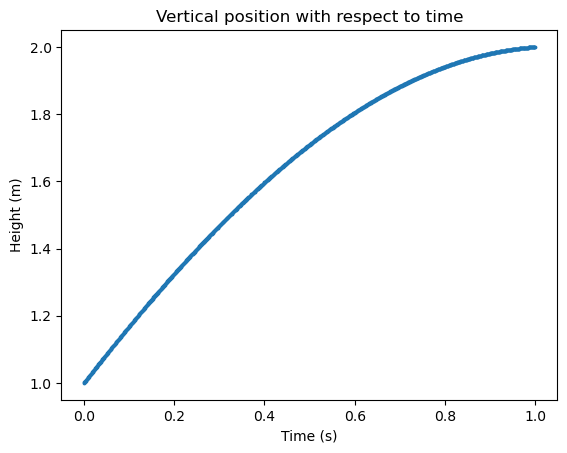

The calculated final y-value is 2.000000000014644 compared to the expected value of 2.


In [19]:

ypoints = np.zeros(len(tpoints),float) #positions
vpoints = np.zeros(len(tpoints),float) #velocities

r = np.array([y0,vinit])
#using 4th order RK to get a graph
for i in range(len(tpoints)):
    t = tpoints[i]
    ypoints[i],vpoints[i] = r[0],r[1]
    k1 = h*f(r,t)
    k2 = h*f(r+0.5*k1,t+0.5*h)
    k3 = h*f(r+0.5*k2,t+0.5*h)
    k4 = h*f(r+k3,t+h)
    r += (1/6)*(k1 + 2*k2 + 2*k3 + k4)
ypoints[i],vpoints[i] = r[0],r[1]

plt.scatter(tpoints,ypoints,s=3)
plt.title('Vertical position with respect to time')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.show()

print('The calculated final y-value is',ypoints[-1],'compared to the expected value of 2.')


We expected a final value of 2 from the stipulated conditions, and the graph returned a value very close to 2. As expected, the graph is concave down, which matches with the original 2nd-order diff eq. The initial conditions found through binary search match our expectations.

### Eigenvalue Problems 

Find the smallest positive eigenvalue $z$ for the equation:
	    $$\frac{d^2y}{dt^2} = -z y$$
	    where $y(t =-1) = 0$ and $y(t = 1) = 0$. Try searching in the range $0.0 \leq z \leq 10.0$. To do this, complete the following steps:

#### Step 1: define the function `f(r,t,z)` that applies values (including your initial guess of $z$ and a vector `r` that containts two elements) to the two first-order differential equations needed for this problem. You may find it beneficial to write our your two first-order differential equations first. 

$\frac{dy}{dt} = v$

$\frac{dv}{dt} = -zy$

In [20]:
def f(r,t,z): #r is an array, t is the variable we differentiate wrt, and z is the eigenvalue
    y = r[0]
    v = r[1]

    fy = v
    fv = -z*y

    return np.array([fy,fv],float)


#### Step 2: Define any constants, time constraints, and initial/boundary values necessay to apply fourth-order runge-kutta and either the binary search or secant method to solve this problem

In [23]:
#define constants
t0 = -1
t1 = 1

N = 1000
h = (t1-t0)/N


#secant method initial guesses
z1 = 0.0
z2 = 10.0



#### Step 3: Solve for $z$ using fourth-order runge-kutta and the root method of your choice (binary, secant)

In [26]:
def y_RK4(z):
    r = np.array([0.0,1.0],float) #initial guesses for y and v (just an arbitrary guess for v of 1 m/s)

    tpoints = np.arange(t0,t1+h,h)

    for t in tpoints: 
        k1 = h*f(r,t,z)
        k2 = h*f(r+0.5*k1,t+0.5*h,z)
        k3 = h*f(r+0.5*k2,t+0.5*h,z)
        k4 = h*f(r+k3,t+h,z)
        r += (1/6)*(k1 + 2*k2 + 2*k3 + k4)
    return r[0] #we want from this the final y, which is r[0]



#determine z using secant method

y2 = y_RK4(z1)

target = 1e-10

while abs(z1-z2) > target: #this in here is the secant method
    y1,y2 = y2,y_RK4(z2) #the old y2 is the new y1, and the new y2 is redefined with the fn

    z1,z2 = z2,z2-y2*(z1-z2)/(y1-y2) #eventually z2 is the final answer

zcalculated = z2

print('The eigenvalue as determined by the secant method is',zcalculated)



The eigenvalue as determined by the secant method is 9.84989476192609


#### Step 4: Does your value of $z$ make sense? Show below by plugging initial conditions back into fourth-order Runge-Kutta and plotting $y$ vs. $t$. What happens if you change the initial guess of $v = \frac{dy}{dt}$? 

The following plot is for eigenvalue z = 9.84989476192609


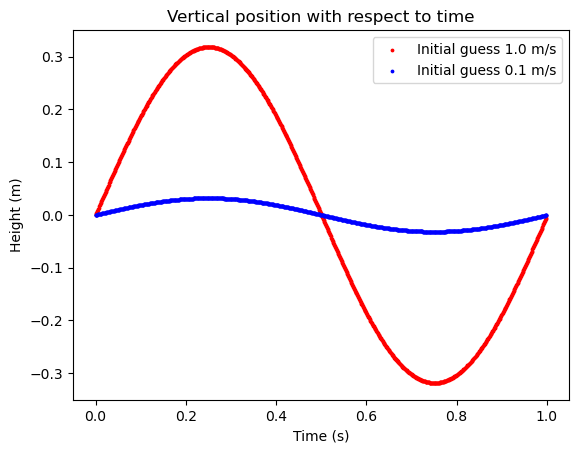

The calculated final y-value is 1.999769021569937 compared to the expected value of 0.


In [36]:

ypoints1 = np.zeros(len(tpoints),float)
vpoints1 = np.zeros(len(tpoints),float)
ypoints2 = np.zeros(len(tpoints),float)
vpoints2 = np.zeros(len(tpoints),float)

def RK4forgraph(ypoints,vpoints,vguess,zcalculated):
    r = np.array([0.0,vguess])
    for i in range(len(tpoints)):
        t = tpoints[i]
        ypoints[i],vpoints[i] = r[0],r[1]
        k1 = h*f(r,t,z2)
        k2 = h*f(r+0.5*k1,t+0.5*h,zcalculated)
        k3 = h*f(r+0.5*k2,t+0.5*h,zcalculated)
        k4 = h*f(r+k3,t+h,zcalculated)
        r += (1/6)*(k1 + 2*k2 + 2*k3 + k4)
    ypoints[i],vpoints[i] = r[0],r[1]
    return ypoints,vpoints

ypoints1,vpoints1 = RK4forgraph(ypoints1,vpoints1,1.0,zcalculated)
ypoints2,vpoints2 = RK4forgraph(ypoints2,vpoints2,0.1,zcalculated)


print('The following plot is for eigenvalue z =',zcalculated)
plt.scatter(tpoints,ypoints1,s=3,c='r',label='Initial guess 1.0 m/s')
plt.scatter(tpoints,ypoints2,s=3,c='b',label='Initial guess 0.1 m/s')
plt.title('Vertical position with respect to time')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.legend()
plt.show()

print('The calculated final y-value is',ypoints[-1],'compared to the expected value of 0.')



I think the z-value is accurate, because the starting and ending is accurate and the shape makes sense (for this form of second order ODE, the nature of motion is oscillatory). Since the boundary conditions are not especially restrictive, any v can be correct with these conditions, so the different v guess changes the slopes without changing the shape of the function.